In [2]:
from pathlib import Path
import json
import sys
from peft import LoraConfig, get_peft_model
import monai
import tqdm
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from skimage import io
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader

from pytorch_ood.detector import KNN
from pytorch_ood.utils import OODMetrics

In [3]:
# -------------------------
# Configuration
# -------------------------
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "pipelines_and_experiments":
    PROJECT_ROOT = PROJECT_ROOT.parent

MEDSAM_ROOT = PROJECT_ROOT / "MedSAM"
MEDSAM_SEGMENTATION_DIR = MEDSAM_ROOT / "notebooks" / "segmentation"


DATA_ROOT_MAMAMIA = "/home/jovyan/thesis_project/datasets/mama_mia/extracted_slices"
DATA_ROOT_INbreast = "/home/jovyan/thesis_project/datasets/INbreast/INbreast Release 1.0/MassCases"

TEST_DATASET = None  # None = use fold with best detection map_50 if available. Or set e.g. "ZGT_VersaMammo_fold4".


DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
MODELS_DIR=Path("/home/jovyan/thesis_project/models")

MEDSAM_CHECKPOINT = MODELS_DIR / "medsam_vit_b.pth"
OUTPUT_ROOT = PROJECT_ROOT / "results" / "pipelines_and_experiments" / "SEG_MAMA_MIA_from_ZGT_medSAM-ZS"

MEDSAM_IMAGE_SIZE = (1024, 1024)
MIN_COMPONENT_AREA = 1
BBOX_PADDING = 0
BBOX_CONNECTIVITY = 2  # 2 = 8-neighborhood; 1 = 4-neighborhood
MASK_THRESHOLD = 0.5
BATCH_SIZE = 1

print(f"Project root: {PROJECT_ROOT}")
print(f"CUDA available: {torch.cuda.is_available()} | device: {DEVICE}")

Project root: /home/jovyan/thesis_project/FM_thesis
CUDA available: True | device: cuda:0


In [4]:
# Imports from this repo and from MedSAM.
# PROJECT_ROOT must be on sys.path so `utils.dep_injection_util` resolves to FM_thesis/utils.
for path in [PROJECT_ROOT, MEDSAM_ROOT, MEDSAM_SEGMENTATION_DIR]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from MedSAM.segment_anything import sam_model_registry
from root_utils.dep_injection_util import (
    BaseDataset,
    NpzLoader,
    ConnectedComponentsBBoxFromMask,
)

In [5]:
def load_json(path: Path):
    with open(path) as f:
        return json.load(f)


MASK_OUT_DIR = OUTPUT_ROOT / "pred_masks"
OVERLAY_OUT_DIR = OUTPUT_ROOT / "overlays"
WEIGHTS_OUT_DIR= OUTPUT_ROOT / "weights"
# METRICS_OUT = OUTPUT_ROOT / "medsam_gt_component_prompt_metrics.csv"
# SUMMARY_OUT = OUTPUT_ROOT / "medsam_gt_component_prompt_summary.json"

print(f"Output root: {OUTPUT_ROOT}")

Output root: /home/jovyan/thesis_project/FM_thesis/results/pipelines_and_experiments/SEG_MAMA_MIA_from_ZGT_medSAM-ZS


In [6]:
class MedSAM(torch.nn.Module):
    def __init__(
        self,
        image_encoder,
        mask_decoder,
        prompt_encoder,
    ):
        super().__init__()
        self.image_encoder = image_encoder
        self.mask_decoder = mask_decoder
        self.prompt_encoder = prompt_encoder
        # freeze prompt encoder
        for param in self.prompt_encoder.parameters():
            param.requires_grad = False

    def forward(self, image, box):
        image_embedding = self.image_encoder(image)  # (B, 256, 64, 64)
        # do not compute gradients for prompt encoder
        with torch.no_grad():
            box_torch = torch.as_tensor(box, dtype=torch.float32, device=image.device)
            if len(box_torch.shape) == 2:
                box_torch = box_torch[:, None, :]  # (B, 1, 4)

            sparse_embeddings, dense_embeddings = self.prompt_encoder(
                points=None,
                boxes=box_torch,
                masks=None,
            )
        low_res_masks, _ = self.mask_decoder(
            image_embeddings=image_embedding,  # (B, 256, 64, 64)
            image_pe=self.prompt_encoder.get_dense_pe(),  # (1, 256, 64, 64)
            sparse_prompt_embeddings=sparse_embeddings,  # (B, 2, 256)
            dense_prompt_embeddings=dense_embeddings,  # (B, 256, 64, 64)
            multimask_output=False,
        )
        ori_res_masks = F.interpolate(
            low_res_masks,
            size=(image.shape[2], image.shape[3]),
            mode="bilinear",
            align_corners=False,
        )
        
        return ori_res_masks

In [7]:
class MedSAMPreprocess:
    """Convert BaseDataset numpy sample into tensors and scale boxes to MedSAM size."""

    def __init__(self, size=(1024, 1024)):
        self.size = tuple(size)

    def __call__(self, sample):
        image = sample["image"]
        mask = sample["mask"]
        boxes = sample["bbox"]

        if image.ndim == 3:
            if image.shape[0] in {1, 3}:
                image = image[0]
            elif image.shape[-1] in {1, 3}:
                image = image[..., 0]
            else:
                raise ValueError(f"Unexpected image shape: {image.shape}")

        if mask.ndim == 3:
            if mask.shape[0] == 1:
                mask = mask[0]
            elif mask.shape[-1] == 1:
                mask = mask[..., 0]
            else:
                raise ValueError(f"Unexpected mask shape: {mask.shape}")

        old_h, old_w = image.shape[:2]
        new_h, new_w = self.size

        image = image.astype(np.float32)
        image = (image - image.min()) / max(float(image.max() - image.min()), 1e-8)
        image_t = torch.from_numpy(image).float().unsqueeze(0).repeat(3, 1, 1)
        image_t = F.interpolate(image_t.unsqueeze(0), size=self.size, mode="bilinear", align_corners=False).squeeze(0)

        mask_t = torch.from_numpy((mask > 0).astype(np.uint8)).float().unsqueeze(0)
        mask_t = F.interpolate(mask_t.unsqueeze(0), size=self.size, mode="nearest").squeeze(0).to(torch.uint8)

        if boxes is None:
            box_t = torch.zeros((0, 4), dtype=torch.float32)
        else:
            box_arr = np.asarray(boxes, dtype=np.float32).reshape(-1, 4)
            box_arr[:, [0, 2]] *= new_w / old_w
            box_arr[:, [1, 3]] *= new_h / old_h
            box_t = torch.from_numpy(box_arr).float()

        sample["image"] = image_t
        sample["mask"] = mask_t
        sample["bbox"] = box_t
        sample["original_size"] = (old_h, old_w)
        sample["resized_size"] = self.size
        return sample

In [41]:
# -------------------------
# Load finetuned checkpoint
# -------------------------

ckpt_path = MODELS_DIR / "medsam_vit_b.pth"
#ckpt_path = MODELS_DIR / "medsam_LoRA_ZGT_from_gt_masks_fold4.pth"

sam_model = sam_model_registry["vit_b"](checkpoint=MEDSAM_CHECKPOINT)

model = MedSAM(
    image_encoder=sam_model.image_encoder,
    mask_decoder=sam_model.mask_decoder,
    prompt_encoder=sam_model.prompt_encoder,
).to(DEVICE)


# config = LoraConfig(
#     r=8,
#     lora_alpha=8,
#     target_modules=["qkv"],
#     lora_dropout=0.1,
#     bias="none"
# )

# model = get_peft_model(model, config)

checkpoint = torch.load(ckpt_path, map_location=DEVICE)
model.load_state_dict(checkpoint["model"])

model.eval()

MedSAM(
  (image_encoder): ImageEncoderViT(
    (patch_embed): PatchEmbed(
      (proj): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (blocks): ModuleList(
      (0-11): 12 x Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (mlp): MLPBlock(
          (lin1): Linear(in_features=768, out_features=3072, bias=True)
          (lin2): Linear(in_features=3072, out_features=768, bias=True)
          (act): GELU(approximate='none')
        )
      )
    )
    (neck): Sequential(
      (0): Conv2d(768, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (1): LayerNorm2d()
      (2): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (3): LayerNorm2d()
   

In [42]:
def mammo_collate_fn(batch):
    collated = {
        "image": torch.stack(
            [sample["image"] for sample in batch], dim=0
        ),
        "mask": torch.stack(
            [sample["mask"] for sample in batch], dim=0
        ),
        "bbox": [sample["bbox"] for sample in batch],
        "label": torch.stack(
            [sample["label"] for sample in batch], dim=0
        ),
        "original_size": [
            sample["original_size"] for sample in batch
        ],
        "case_id": [
            sample.get("case_id") for sample in batch
        ],
        "image_path": [
            sample.get("image_path") for sample in batch
        ],
        "mask_path": [
            sample.get("mask_path") for sample in batch
        ],
    }

    # Include scores after they have been attached to the dataset
    if all("ood_score" in sample for sample in batch):
        collated["ood_score"] = torch.as_tensor(
            [sample["ood_score"] for sample in batch],
            dtype=torch.float32,
        )
        
    if all("ood_score_raw" in sample for sample in batch):
        collated["ood_score_raw"] = torch.as_tensor(
            [sample["ood_score_raw"] for sample in batch],
            dtype=torch.float32,
        )

    # Include metadata when return_metadata=True
    if all("metadata" in sample for sample in batch):
        collated["metadata"] = [
            sample["metadata"] for sample in batch
        ]

    return collated

In [43]:
loader = NpzLoader(dtype=None)

bbox_generator = ConnectedComponentsBBoxFromMask(
    annotation_threshold=0.5,
    min_mask_area=MIN_COMPONENT_AREA,
    bbox_padding=BBOX_PADDING,
    connectivity=BBOX_CONNECTIVITY,
    allow_empty_mask=True,
)



mamamia_test_dataset = BaseDataset(
    root=DATA_ROOT_MAMAMIA,
    format_loader=loader,
    bbox_generator=bbox_generator,
    transforms=MedSAMPreprocess(MEDSAM_IMAGE_SIZE),
    split="all",
    return_metadata=False,
)

inbreast_test_dataset = BaseDataset(
    root=DATA_ROOT_INbreast,
    format_loader=loader,
    bbox_generator=bbox_generator,
    transforms=MedSAMPreprocess(MEDSAM_IMAGE_SIZE),
    split="all",
    return_metadata=False,
)



In [44]:
def dice_score(pred_mask: torch.Tensor, gt_mask: torch.Tensor) -> float:
    pred = pred_mask.bool()
    gt = gt_mask.bool()
    denom = pred.sum() + gt.sum()
    if denom.item() == 0:
        return 1.0
    return float((2 * (pred & gt).sum() / denom).item())



def to_display_image(image_tensor: torch.Tensor) -> np.ndarray:
    img = image_tensor.detach().cpu().permute(1, 2, 0).numpy()
    img = (img - img.min()) / max(float(img.max() - img.min()), 1e-8)
    return img


def overlay_result(image_tensor, gt_mask, pred_mask, boxes, title, out_path):
    image = to_display_image(image_tensor)
    gt = gt_mask.detach().cpu().squeeze().numpy().astype(bool)
    pred = pred_mask.detach().cpu().squeeze().numpy().astype(bool)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image, cmap="gray")

    gt_rgba = np.zeros((*gt.shape, 4), dtype=np.float32)
    gt_rgba[..., 1] = 1.0
    gt_rgba[..., 3] = gt * 0.35
    ax.imshow(gt_rgba)

    pred_rgba = np.zeros((*pred.shape, 4), dtype=np.float32)
    pred_rgba[..., 0] = 1.0
    pred_rgba[..., 3] = pred * 0.35
    ax.imshow(pred_rgba)

    for i, box in enumerate(boxes.detach().cpu().numpy() if boxes is not None else []):
        x1, y1, x2, y2 = box.tolist()
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="yellow", linewidth=1.5)
        ax.add_patch(rect)
        ax.text(x1, max(0, y1 - 4), f"component {i + 1}", color="black", fontsize=8, bbox={"facecolor": "yellow", "alpha": 0.8, "pad": 1})

    ax.set_title(title)
    ax.set_axis_off()
    out_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(out_path, bbox_inches="tight", pad_inches=0, dpi=160)
    plt.close(fig)

### OOD scores retriever

In [39]:
# id_path="/home/jovyan/thesis_project/FM_thesis/feature_space_inspection/MedSAM_zs_ZGT_masses"

# Z_id=torch.load(id_path)
# Y_id=torch.zeros(Z_id.shape[0],dtype=torch.long)

# #fit on ID data
# det = KNN(encoder=None)
# det.fit_features(Z_id, Y_id)


# features = []
# sample_indices = []

# with torch.no_grad():
#     for idx, sample in enumerate(inbreast_test_dataset):
#         imgs = sample["image"].unsqueeze(0).to(DEVICE)

#         z = model.image_encoder(imgs)
#         z = z.mean(dim=(2, 3))

#         features.append(z.cpu())
#         sample_indices.append(idx)

# Z_ood = torch.cat(features, dim=0)
# scores_ood = det.predict_features(Z_ood)
# scores_norm = (scores_ood - scores_ood.min()) / (scores_ood.max() - scores_ood.min())

# for idx, score in zip(sample_indices, scores_norm):
#     zgt_test_dataset.files[idx]["ood_score"] = (
#         score.item() if hasattr(score, "item") else float(score)
#     )

In [45]:
from pathlib import Path
import torch

id_path = Path(
    "/home/jovyan/thesis_project/FM_thesis/"
    "feature_space_inspection/MedSAM_zs_ZGT_masses"
)

# Load and prepare ID features
Z_id = torch.load(id_path, map_location="cpu")
Y_id = torch.zeros(Z_id.shape[0], dtype=torch.long)

# Fit KNN detector on ID features
det = KNN(encoder=None)
det.fit_features(Z_id, Y_id)


def extract_features(dataset, model, device):
    """Extract one feature vector for every sample in a dataset."""
    features = []
    sample_indices = []

    with torch.no_grad():
        for idx, sample in enumerate(dataset):
            imgs = sample["image"].unsqueeze(0).to(device)

            z = model.image_encoder(imgs)
            z = z.mean(dim=(2, 3))

            features.append(z.cpu())
            sample_indices.append(idx)

    if not features:
        raise ValueError("The dataset contains no samples.")

    return torch.cat(features, dim=0), sample_indices


def append_scores_to_dataset(
    dataset,
    sample_indices,
    raw_scores,
    normalized_scores,
):
    """Append raw and normalized OOD scores to each evaluated image."""
    if not hasattr(dataset, "files"):
        raise AttributeError(
            "The dataset has no `files` attribute in which to store scores."
        )

    for idx, raw_score, norm_score in zip(
        sample_indices,
        raw_scores,
        normalized_scores,
    ):
        dataset.files[idx]["ood_score_raw"] = float(raw_score.item())
        dataset.files[idx]["ood_score"] = float(norm_score.item())


# Extract features from both OOD datasets
Z_mamamia, mamamia_indices = extract_features(
    mamamia_test_dataset,
    model,
    DEVICE,
)

Z_inbreast, inbreast_indices = extract_features(
    inbreast_test_dataset,
    model,
    DEVICE,
)

# Compute KNN OOD scores
scores_mamamia = torch.as_tensor(
    det.predict_features(Z_mamamia),
    dtype=torch.float32,
)

scores_inbreast = torch.as_tensor(
    det.predict_features(Z_inbreast),
    dtype=torch.float32,
)

# Joint normalization keeps scores comparable across the two datasets
all_scores = torch.cat(
    [scores_mamamia, scores_inbreast],
    dim=0,
)

score_min = all_scores.min()
score_max = all_scores.max()
score_range = score_max - score_min

if score_range > 0:
    scores_mamamia_norm = (scores_mamamia - score_min) / score_range
    scores_inbreast_norm = (scores_inbreast - score_min) / score_range
else:
    # Avoid division by zero when every score is identical
    scores_mamamia_norm = torch.zeros_like(scores_mamamia)
    scores_inbreast_norm = torch.zeros_like(scores_inbreast)

# Append each score to the dataset from which the image came
append_scores_to_dataset(
    mamamia_test_dataset,
    mamamia_indices,
    scores_mamamia,
    scores_mamamia_norm,
)

append_scores_to_dataset(
    inbreast_test_dataset,
    inbreast_indices,
    scores_inbreast,
    scores_inbreast_norm,
)

In [40]:
sum_scores=0
for score in scores_norm:
    sum_scores+=score
    
avg=sum_scores/len(scores_norm)

print(avg)

tensor(0.4348, dtype=torch.float64)


In [46]:
mamamia_test_loader = DataLoader(
    mamamia_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=mammo_collate_fn,
)


inbreast_test_loader = DataLoader(
    inbreast_test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    collate_fn=mammo_collate_fn,
)


print(f"Loaded {len(mamamia_test_loader)} mamamia train images")
print(f"Loaded {len(inbreast_test_loader)} inbreast train images")

Loaded 171 mamamia train images
Loaded 108 inbreast train images


In [16]:
batch=next(iter(mamamia_test_loader))

print(batch.keys())

dict_keys(['image', 'mask', 'bbox', 'label', 'original_size', 'case_id', 'image_path', 'mask_path', 'ood_score', 'ood_score_raw'])


In [47]:
def forward_medsam_multi_box_batch(model, images, boxes_batch, device):
    """
    images: (B, C, H, W)
    boxes_batch: list length B, each item is (K_i, 4)
    returns: (B, 1, H, W)
    """

    batch_logits = []

    for i in range(images.shape[0]):
        
        image_i = images[i].unsqueeze(0)  # (1, C, H, W)
        boxes_i = boxes_batch[i]

        
        if boxes_i is None or len(boxes_i) == 0:
            _, _, H, W = images.shape
            empty_logits = torch.zeros(
                (1, 1, H, W),
                device=device,
                dtype=images.dtype,
            )
            batch_logits.append(empty_logits)
            continue

        logits_per_box = []

        for box in boxes_i:
            
            box = torch.as_tensor(box, dtype=torch.float32, device=device)

            if box.ndim == 1:
                box = box.unsqueeze(0)  # (4,) -> (1, 4)


            pred_logits = model(image_i, box)
            logits_per_box.append(pred_logits)

        logits_per_box = torch.cat(logits_per_box, dim=0)
        union_logits = logits_per_box.max(dim=0, keepdim=True).values

        batch_logits.append(union_logits)

    batch_logits = torch.cat(batch_logits, dim=0)

    return batch_logits

In [48]:
MASK_OUT_DIR.mkdir(parents=True, exist_ok=True)
OVERLAY_OUT_DIR.mkdir(parents=True, exist_ok=True)

rows = []

test_loaders = {
    "mamamia": mamamia_test_loader,
    "inbreast": inbreast_test_loader,
}

with torch.no_grad():
    for dataset_name, test_loader in test_loaders.items():
        print(f"Evaluating {dataset_name}...")

        for batch_idx, batch in enumerate(test_loader, start=1):
            images = batch["image"].to(DEVICE)
            gt_masks = batch["mask"].to(DEVICE).float()
            ood_scores = batch["ood_score"].to(DEVICE).float()

            boxes_list = batch["bbox"]
            case_ids = batch["case_id"]

            boxes_batch = [
                box.to(DEVICE).float()
                if torch.is_tensor(box)
                else torch.as_tensor(
                    box,
                    dtype=torch.float32,
                    device=DEVICE,
                )
                for box in boxes_list
            ]

            medsam_logits = forward_medsam_multi_box_batch(
                model,
                images,
                boxes_batch,
                DEVICE,
            )

            pred_masks = (
                torch.sigmoid(medsam_logits) > MASK_THRESHOLD
            ).float()

            for i in range(images.shape[0]):
                image = images[i]
                gt_mask = gt_masks[i]
                pred_mask = pred_masks[i]
                boxes = boxes_batch[i]

                case_id = case_ids[i]
                ood_score = ood_scores[i]

                dice = dice_score(
                    pred_mask,
                    gt_mask,
                )

                # Include the dataset name to avoid filename collisions
                output_id = f"{dataset_name}_{case_id}"

                # io.imsave(
                #     MASK_OUT_DIR / f"{output_id}_pred_union.png",
                #     (
                #         pred_mask.detach()
                #         .cpu()
                #         .squeeze()
                #         .numpy()
                #         * 255
                #     ).astype(np.uint8),
                #     check_contrast=False,
                # )

                # overlay_result(
                #     image_tensor=image.detach().cpu(),
                #     gt_mask=gt_mask.detach().cpu(),
                #     pred_mask=pred_mask.detach().cpu(),
                #     boxes=boxes.detach().cpu(),
                #     title=(
                #         f"{output_id} | "
                #         f"Dice={float(dice):.3f} | "
                #         f"OOD={float(ood_score):.3f} | "
                #         f"component prompts={len(boxes)}"
                #     ),
                #     out_path=OVERLAY_OUT_DIR / f"{output_id}.png",
                # )

                rows.append({
                    "dataset": dataset_name,
                    "case_id": case_id,
                    "dice": float(dice),
                    "ood_score": float(ood_score),
                    "pred_mask": pred_mask.detach().cpu(),
                    "num_component_boxes": int(len(boxes)),
                    "gt_area": int(gt_mask.bool().sum().item()),
                    "pred_area": int(pred_mask.bool().sum().item()),
                })

            if batch_idx % 5 == 0 or batch_idx == len(test_loader):
                print(
                    f"{dataset_name}: processed batch "
                    f"{batch_idx}/{len(test_loader)}"
                )

Evaluating mamamia...
mamamia: processed batch 5/171
mamamia: processed batch 10/171
mamamia: processed batch 15/171
mamamia: processed batch 20/171
mamamia: processed batch 25/171
mamamia: processed batch 30/171
mamamia: processed batch 35/171
mamamia: processed batch 40/171
mamamia: processed batch 45/171
mamamia: processed batch 50/171
mamamia: processed batch 55/171
mamamia: processed batch 60/171
mamamia: processed batch 65/171
mamamia: processed batch 70/171
mamamia: processed batch 75/171
mamamia: processed batch 80/171
mamamia: processed batch 85/171
mamamia: processed batch 90/171
mamamia: processed batch 95/171
mamamia: processed batch 100/171
mamamia: processed batch 105/171
mamamia: processed batch 110/171
mamamia: processed batch 115/171
mamamia: processed batch 120/171
mamamia: processed batch 125/171
mamamia: processed batch 130/171
mamamia: processed batch 135/171
mamamia: processed batch 140/171
mamamia: processed batch 145/171
mamamia: processed batch 150/171
mamamia:

In [34]:
for idx, sample in enumerate(rows):
    print(f"{idx}:{sample['dice']}, {sample['ood_score']}")

0:0.9015672206878662, 0.2639128565788269
1:0.7373020648956299, 0.284309983253479
2:0.6645962595939636, 0.29483678936958313
3:0.8466611504554749, 0.568288266658783
4:0.8379088044166565, 0.5444655418395996
5:0.7652143239974976, 0.3836241364479065
6:0.9125872254371643, 0.6289406418800354
7:0.7524407505989075, 0.4414568543434143
8:0.8582844734191895, 0.31064674258232117
9:0.8651766180992126, 0.4643290638923645
10:0.9217602014541626, 0.35814157128334045
11:0.8701800107955933, 0.2493530660867691
12:0.8063806891441345, 0.4183826148509979
13:0.802214503288269, 0.32835808396339417
14:0.9215759634971619, 0.19859538972377777
15:0.6604510545730591, 0.3676828444004059
16:0.7894963026046753, 0.1369827389717102
17:0.679341197013855, 0.40678709745407104
18:0.8987275958061218, 0.31044498085975647
19:0.6903615593910217, 0.2006235271692276
20:0.8222617506980896, 0.3603070378303528
21:0.9537081718444824, 0.40828749537467957
22:0.6805455684661865, 0.37511691451072693
23:0.8751380443572998, 0.19215197861194


mamamia
Number of samples: 171
OOD range: 0.019847 to 0.620681
Dice range: 0.182970 to 0.966221
Pearson r: -0.120837
p-value: 1.154107e-01

inbreast
Number of samples: 108
OOD range: 0.000000 to 1.000000
Dice range: 0.527991 to 1.000000
Pearson r: -0.283544
p-value: 2.942584e-03


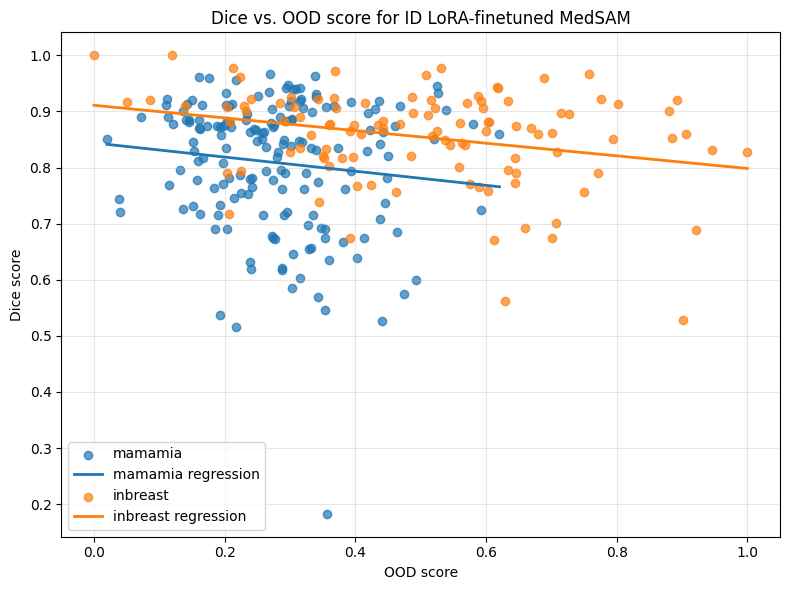

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

plt.figure(figsize=(8, 6))

colors = {
    "mamamia": "tab:blue",
    "inbreast": "tab:orange",
}

for dataset in ["mamamia", "inbreast"]:
    dataset_rows = [r for r in rows if r["dataset"] == dataset]

    ood_scores = np.asarray(
        [r["ood_score"] for r in dataset_rows],
        dtype=np.float64,
    )
    dice_scores = np.asarray(
        [r["dice"] for r in dataset_rows],
        dtype=np.float64,
    )

    # Remove invalid values
    valid = np.isfinite(ood_scores) & np.isfinite(dice_scores)
    ood_scores = ood_scores[valid]
    dice_scores = dice_scores[valid]

    print(f"\n{dataset}")
    print(f"Number of samples: {len(ood_scores)}")
    print(
        f"OOD range: {ood_scores.min():.6f} "
        f"to {ood_scores.max():.6f}"
    )
    print(
        f"Dice range: {dice_scores.min():.6f} "
        f"to {dice_scores.max():.6f}"
    )

    if len(ood_scores) < 2:
        print("Not enough samples to compute correlation.")
        continue

    if np.isclose(ood_scores.std(), 0):
        print("OOD scores are constant; correlation is undefined.")
        continue

    if np.isclose(dice_scores.std(), 0):
        print("Dice scores are constant; correlation is undefined.")
        continue

    r, p = pearsonr(ood_scores, dice_scores)

    print(f"Pearson r: {r:.6f}")
    print(f"p-value: {p:.6e}")

    plt.scatter(
        ood_scores,
        dice_scores,
        alpha=0.7,
        color=colors[dataset],
        label=dataset,
    )

    coeffs = np.polyfit(ood_scores, dice_scores, deg=1)
    trend = np.poly1d(coeffs)

    x = np.linspace(
        ood_scores.min(),
        ood_scores.max(),
        100,
    )

    plt.plot(
        x,
        trend(x),
        color=colors[dataset],
        linewidth=2,
        label=f"{dataset} regression",
    )

plt.xlabel("OOD score")
plt.ylabel("Dice score")
plt.title("Dice vs. OOD score for ID LoRA-finetuned MedSAM")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(
    "MedSAM_zs_OOD_distance_vs_DICE_Mamamia_INbreast.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [46]:
from scipy.stats import pearsonr

r, p = pearsonr(ood_scores, dice_scores)

print(f"Pearson r: {r:.3f}")
print(f"p-value: {p:.3e}")

Pearson r: -0.121
p-value: 1.154e-01


In [53]:
sum_ood=0
ct=0
for sample in rows:
    if sample["dataset"]=="mamamia":
        sample_ood_score=sample["ood_score"]
        sum_ood+=sample_ood_score
        ct+=1
    
avg=sum_ood/ct

print(avg)
    

0.2811079010672388


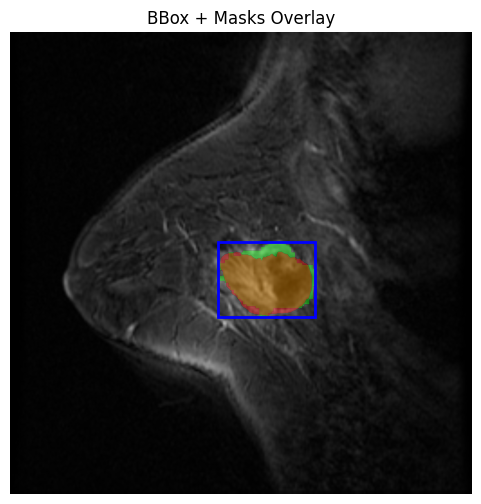

In [53]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np


def show_bbox_overlay(image, bbox, gt_mask=None, pred_mask=None):
    """
    Overlay bbox (+ optional masks) on an image.

    Parameters
    ----------
    image : torch.Tensor or np.ndarray
        Shape can be (H,W), (H,W,C), or (C,H,W)
    bbox : array-like
        Shape (4,) or (1,4), format [x_min, y_min, x_max, y_max]
    gt_mask : torch.Tensor or np.ndarray, optional
    pred_mask : torch.Tensor or np.ndarray, optional
    """

    def to_numpy(x):
        if x is None:
            return None

        if torch.is_tensor(x):
            x = x.detach().cpu().numpy()

        return x

    image = to_numpy(image)
    gt_mask = to_numpy(gt_mask)
    pred_mask = to_numpy(pred_mask)
    bbox = to_numpy(bbox)

    # Convert image from (C,H,W) -> (H,W,C)
    if image is not None:
        if image.ndim == 3 and image.shape[0] in [1, 3, 4]:
            image = np.transpose(image, (1, 2, 0))

        # Convert (H,W,1) -> (H,W)
        if image.ndim == 3 and image.shape[-1] == 1:
            image = image[..., 0]

    # Squeeze masks to (H,W)
    if gt_mask is not None:
        gt_mask = np.squeeze(gt_mask)

    if pred_mask is not None:
        pred_mask = np.squeeze(pred_mask)

    fig, ax = plt.subplots(figsize=(6, 6))

    # Show image
    if image is not None:
        if image.ndim == 2:
            ax.imshow(image, cmap="gray")
        else:
            ax.imshow(image)

    # GT mask (green)
    if gt_mask is not None:
        gt = np.zeros((*gt_mask.shape, 4))
        gt[..., 1] = gt_mask
        gt[..., 3] = gt_mask * 0.4
        ax.imshow(gt)

    # Pred mask (red)
    if pred_mask is not None:
        pred = np.zeros((*pred_mask.shape, 4))
        pred[..., 0] = pred_mask
        pred[..., 3] = pred_mask * 0.4
        ax.imshow(pred)

    # Handle bbox shape (4,) or (1,4)
    bbox = np.asarray(bbox)

    if bbox.ndim == 2:
        bbox = bbox[0]

    x_min, y_min, x_max, y_max = bbox

    rect = patches.Rectangle(
        (x_min, y_min),
        x_max - x_min,
        y_max - y_min,
        linewidth=2,
        edgecolor="blue",
        facecolor="none",
    )

    ax.add_patch(rect)

    ax.set_title("BBox + Masks Overlay")
    ax.axis("off")
    plt.show()

sample=zgt_test_dataset[120]
    
img=sample["image"]
bbox=sample["bbox"]
gt_mask_sample = sample["mask"]
pred_mask_sample = rows[120]["pred_mask"]



show_bbox_overlay(
    image=img,           # or your original image if you have it
    bbox=bbox,
    gt_mask=gt_mask_sample,
    pred_mask=pred_mask_sample
)

DecompressionBombError: Image size (1759151885 pixels) exceeds limit of 178956970 pixels, could be decompression bomb DOS attack.

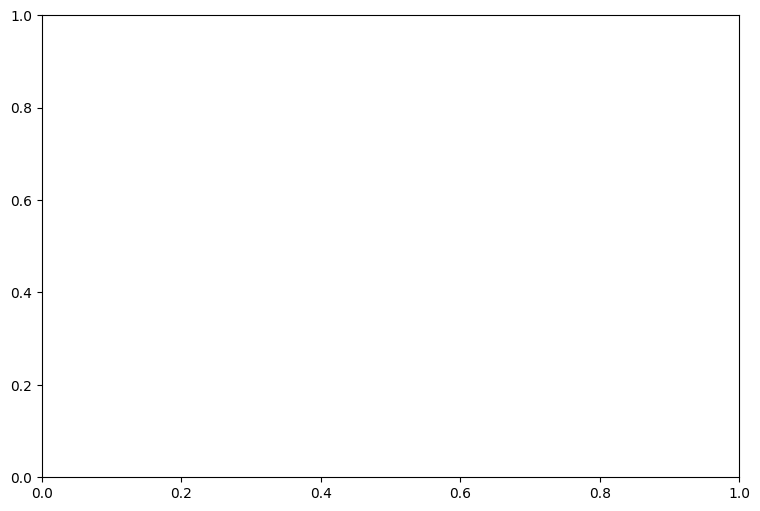

In [33]:
# Preview a few overlays.
preview_paths = sorted(OVERLAY_OUT_DIR.glob("*.png"))[:6]
if not preview_paths:
    print("No overlays generated yet.")
else:
    fig, axes = plt.subplots(len(preview_paths), 1, figsize=(9, 6 * len(preview_paths)))
    if len(preview_paths) == 1:
        axes = [axes]
    for ax, path in zip(axes, preview_paths):
        ax.imshow(io.imread(path))
        ax.set_title(path.name)
        ax.set_axis_off()
    plt.tight_layout()